# Practical 5: Continuous Bag of Words (CBOW) Model

**Aim:** Implement the CBOW model to learn word embeddings (word vectors) from a text corpus.

**Dataset:** `datasets/cbow_corpus.txt`, small data.

**Idea of CBOW:** predict the middle (target) word from the words around it (context).

```
"the  encoder  [compresses]  the  input"
 context    ->   target   <-   context
```

To make good predictions, the model must learn a vector for every word such that words used in similar contexts get similar vectors. Those learned vectors are the **word embeddings**.

**Stages (as per syllabus):**
- a. Data preparation
- b. Generate training data
- c. Train model
- d. Output

In [45]:
# ---------------------------------------------------------------
# Common setup: imports, reproducibility, and offline data folder
# ---------------------------------------------------------------
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow INFO/WARNING logs so outputs stay readable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# Fix the random seeds (Python, NumPy, TensorFlow) so every run gives similar numbers.
# This makes it easy to compare results between students.
keras.utils.set_random_seed(42)

# All data is read from the local "datasets" folder that sits next to this notebook.
DATA_DIR = Path("datasets")
# MODEL_DIR = Path("models")
assert DATA_DIR.exists(), "datasets folder not found"

In [46]:
import re
from collections import Counter
from sklearn.decomposition import PCA

## Stage a: Data preparation

1. Read the text and split it into sentences (one per line).
2. Lowercase and keep only letters, so "Network," and "network" become the same token.
3. Split every sentence into words (tokens).
4. Build the vocabulary: give every unique word an integer id. Id `0` is reserved for padding.

In [47]:
text = (DATA_DIR / "cbow_corpus.txt").read_text(encoding="utf-8")
print("Characters in corpus:", len(text))
print("First 300 characters:\n", text[:300])

Characters in corpus: 5425
First 300 characters:
 Deep learning is a branch of machine learning that uses neural networks with many layers.
A neural network is made of layers of neurons, and every neuron computes a weighted sum of its inputs.
The weighted sum is passed through an activation function such as relu or sigmoid.
The first layer is the i


In [48]:
def tokenize(sentence):
    """ 
    function to remove digits and punctuations using regular expressions and then tokenizing the data
    """
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z\s]", " ", sentence)   # remove punctuation and digits
    return sentence.split()

sentences = [tokenize(line) for line in text.split("\n") if line.strip()]
all_words = [w for s in sentences for w in s]

print("Number of sentences:", len(sentences))
print("Total words        :", len(all_words))
print("Example tokenized sentence:", sentences[0])

Number of sentences: 61
Total words        : 920
Example tokenized sentence: ['deep', 'learning', 'is', 'a', 'branch', 'of', 'machine', 'learning', 'that', 'uses', 'neural', 'networks', 'with', 'many', 'layers']


In [49]:
# Word frequencies: frequent words appear in many contexts
freq = Counter(all_words)
print("Unique words:", len(freq))
print("20 most common words:")
for w, c in freq.most_common(20):
    print(f"  {w:<12} {c}")

Unique words: 313
20 most common words:
  the          114
  a            38
  and          34
  is           27
  of           24
  network      20
  model        14
  to           13
  loss         11
  data         11
  word         11
  learning     10
  training     10
  words        10
  layers       9
  an           9
  layer        9
  that         8
  with         8
  we           8


In [52]:
# Vocabulary: most frequent word gets id 1, and so on. Id 0 = <pad>.
PAD = "<pad>"
idx2word = [PAD] + [w for w, _ in freq.most_common()]
word2idx = {w: i for i, w in enumerate(idx2word)}
VOCAB_SIZE = len(idx2word)

print("Vocabulary size (including <pad>):", VOCAB_SIZE)
print("Some mappings:", {w: word2idx[w] for w in["machine", "deep", "neural"]})

# Convert every sentence from words to ids
encoded = [[word2idx[w] for w in s] for s in sentences]
print("\nSentence as words:", sentences[0][:8])
print("Sentence as ids  :", encoded[0][:8])

Vocabulary size (including <pad>): 314
Some mappings: {'machine': 138, 'deep': 40, 'neural': 24}

Sentence as words: ['deep', 'learning', 'is', 'a', 'branch', 'of', 'machine', 'learning']
Sentence as ids  : [40, 12, 4, 2, 137, 5, 138, 12]


## Stage b: Generate training data

For every word in every sentence, the **target** is that word and the **context** is up to `WINDOW` words on each side.
Words near the start or end of a sentence have fewer neighbours, so the context is padded with id 0 (`<pad>`) to a fixed length of `2 * WINDOW`.

In [53]:
WINDOW = 2
CONTEXT_LEN = 2 * WINDOW

contexts, targets = [], []
for sent in encoded:
    for i, target in enumerate(sent):
        left = sent[max(0, i - WINDOW): i]
        right = sent[i + 1: i + 1 + WINDOW]
        ctx = left + right
        ctx = ctx + [0] * (CONTEXT_LEN - len(ctx))    # pad to fixed length
        contexts.append(ctx)
        targets.append(target)

X = np.array(contexts, dtype="int32")
y = np.array(targets, dtype="int32")
print("X (contexts) shape:", X.shape, "| y (targets) shape:", y.shape)

X (contexts) shape: (920, 4) | y (targets) shape: (920,)


In [54]:
# Inspect the first 12 training pairs in words, to see exactly what the model learns from
for ctx, tgt in zip(X[:12], y[:12]):
    ctx_words = [idx2word[i] for i in ctx]
    print(f"{str(ctx_words):<55} -> {idx2word[tgt]}")

['learning', 'is', '<pad>', '<pad>']                    -> deep
['deep', 'is', 'a', '<pad>']                            -> learning
['deep', 'learning', 'a', 'branch']                     -> is
['learning', 'is', 'branch', 'of']                      -> a
['is', 'a', 'of', 'machine']                            -> branch
['a', 'branch', 'machine', 'learning']                  -> of
['branch', 'of', 'learning', 'that']                    -> machine
['of', 'machine', 'that', 'uses']                       -> learning
['machine', 'learning', 'uses', 'neural']               -> that
['learning', 'that', 'neural', 'networks']              -> uses
['that', 'uses', 'networks', 'with']                    -> neural
['uses', 'neural', 'with', 'many']                      -> networks


## Stage c: Train model

CBOW architecture:

```
context ids (4)  ->  Embedding (VOCAB_SIZE x 50)  ->  4 vectors of size 50
                 ->  Average of the 4 vectors      ->  1 vector of size 50
                 ->  Dense(VOCAB_SIZE, softmax)    ->  probability of every word being the target
```

- `Embedding` is a lookup table: row `i` is the vector of word `i`. These rows are the word embeddings we want.
- `mask_zero=True` tells Keras that id 0 is padding, so the averaging layer ignores padded positions.
- Loss: `sparse_categorical_crossentropy`, because the target is one word id out of the whole vocabulary.

In [55]:
EMBED_DIM = 50

cbow = keras.Sequential([
    keras.Input(shape=(CONTEXT_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="embedding"),
    layers.GlobalAveragePooling1D(name="average_context"),
    layers.Dense(VOCAB_SIZE, activation="softmax", name="predict_target"),
], name="cbow")
cbow.summary()
print("Embedding parameters = VOCAB_SIZE x EMBED_DIM =", VOCAB_SIZE, "x", EMBED_DIM, "=", VOCAB_SIZE * EMBED_DIM)

Model: "cbow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 50)          │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_context                 │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predict_target (Dense)          │ (None, 314)            │        16,014 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,714 (123.88 KB)

 Trainable params: 31,714 (123.88 KB)

 Non-trainable params: 0 (0.00 B)

Embedding parameters = VOCAB_SIZE x EMBED_DIM = 314 x 50 = 15700


In [56]:
# Inspect the data flow for one example
emb_layer = cbow.get_layer("embedding")
one = X[5:6]
vecs = emb_layer(one)
print("context ids          :", one[0], "->", [idx2word[i] for i in one[0]])
print("after Embedding      :", tuple(vecs.shape), "(1 sample, 4 context words, 50 numbers each)")
avg = cbow.get_layer("average_context")(vecs, mask=emb_layer.compute_mask(one))
print("after averaging      :", tuple(avg.shape))
print("final output         :", tuple(cbow(one).shape), "(one probability per vocabulary word)")

context ids          : [  2 137 138  12] -> ['a', 'branch', 'machine', 'learning']
after Embedding      : (1, 4, 50) (1 sample, 4 context words, 50 numbers each)
after averaging      : (1, 50)
final output         : (1, 314) (one probability per vocabulary word)


In [57]:
cbow.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

history = cbow.fit(X, y, epochs=60, batch_size=64, shuffle=True, verbose=1)



Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0880 - loss: 5.6954      
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1641 - loss: 5.2578 
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1652 - loss: 4.6611 
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1902 - loss: 4.2212 
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2478 - loss: 3.7946 
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2880 - loss: 3.3739 
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3522 - loss: 2.9628 
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4272 - loss: 2.5730 
Epoch 9/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5120 - loss: 2.2105 
Epoch 10/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5957 - loss: 1.8795 
Epoch 11/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6685 - loss: 1.5829 
Epoch 12/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accur

final loss: 0.0493 | final accuracy: 0.9761


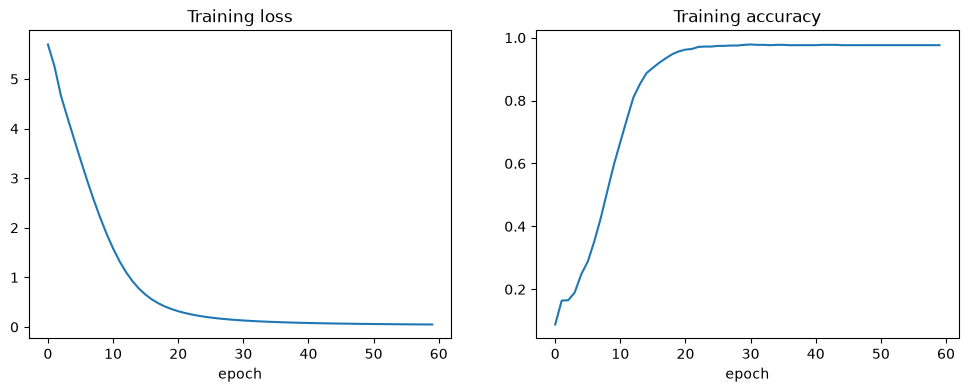

In [58]:
print(f"final loss: {history.history['loss'][-1]:.4f} | final accuracy: {history.history['accuracy'][-1]:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["loss"]); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history.history["accuracy"]); ax[1].set_title("Training accuracy"); ax[1].set_xlabel("epoch")
plt.show()

## Stage d: Output

1. The learned embedding matrix and the vector of a word.
2. Predict a missing target word from its context.
3. Find the most similar words using cosine similarity.
4. Plot word vectors in 2-D.

In [59]:
embeddings = cbow.get_layer("embedding").get_weights()[0]
print("Embedding matrix shape:", embeddings.shape, "-> one 50-number vector per word")
print("Vector for 'encoder' (first 10 of 50 numbers):", np.round(embeddings[word2idx["encoder"]][:10], 3))

Embedding matrix shape: (314, 50) -> one 50-number vector per word
Vector for 'encoder' (first 10 of 50 numbers): [-0.391  0.547  1.487 -0.083  0.338  1.386  1.896  1.083 -0.039 -1.478]


In [60]:
def predict_target(context_words, top_k=5):
    ids = [word2idx.get(w, 0) for w in context_words]
    ids = ids + [0] * (CONTEXT_LEN - len(ids))
    probs = cbow.predict(np.array([ids]), verbose=0)[0]
    best = probs.argsort()[::-1][:top_k]
    return [(idx2word[i], round(float(probs[i]), 3)) for i in best]

tests = [
    ["the", "compresses", "the"],              # the [encoder] compresses the
    ["the", "learning", "controls", "how"],     # the learning [rate] controls
    ["a", "neural", "is", "made"],              # a neural [network] is made
    ["gradient", "is", "the"],                 # gradient [descent] is the
]
for ctx in tests:
    print(f"context {ctx} -> top predictions {predict_target(ctx)}")

context ['the', 'compresses', 'the'] -> top predictions [('encoder', 0.968), ('input', 0.014), ('size', 0.012), ('layer', 0.001), ('decides', 0.001)]
context ['the', 'learning', 'controls', 'how'] -> top predictions [('rate', 0.989), ('if', 0.003), ('well', 0.001), ('wrong', 0.001), ('controls', 0.001)]
context ['a', 'neural', 'is', 'made'] -> top predictions [('network', 0.988), ('layers', 0.006), ('is', 0.005), ('and', 0.0), ('layer', 0.0)]
context ['gradient', 'is', 'the'] -> top predictions [('descent', 0.993), ('of', 0.002), ('computes', 0.001), ('predicted', 0.0), ('batch', 0.0)]


In [61]:
def most_similar(word, top_k=6):
    v = embeddings[word2idx[word]]
    norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(v) + 1e-9
    sims = embeddings @ v / norms                 # cosine similarity with every word
    best = sims.argsort()[::-1]
    return [(idx2word[i], round(float(sims[i]), 3)) for i in best
            if i not in (0, word2idx[word])][:top_k]

for w in ["encoder", "loss", "image", "training", "words"]:
    print(f"{w:<10} -> {most_similar(w)}")

encoder    -> [('colours', 0.652), ('representation', 0.649), ('mistakes', 0.611), ('looks', 0.591), ('then', 0.588), ('validation', 0.574)]
loss       -> [('changes', 0.626), ('common', 0.565), ('most', 0.505), ('matrix', 0.498), ('mistakes', 0.492), ('tensorflow', 0.431)]
image      -> [('colours', 0.491), ('mistakes', 0.481), ('anomaly', 0.457), ('predicting', 0.454), ('decoder', 0.449), ('machine', 0.43)]
training   -> [('normal', 0.544), ('batches', 0.467), ('test', 0.44), ('decides', 0.408), ('convolution', 0.395), ('helps', 0.364)]
words      -> [('predictions', 0.546), ('real', 0.474), ('already', 0.431), ('continuous', 0.419), ('right', 0.418), ('regularization', 0.41)]


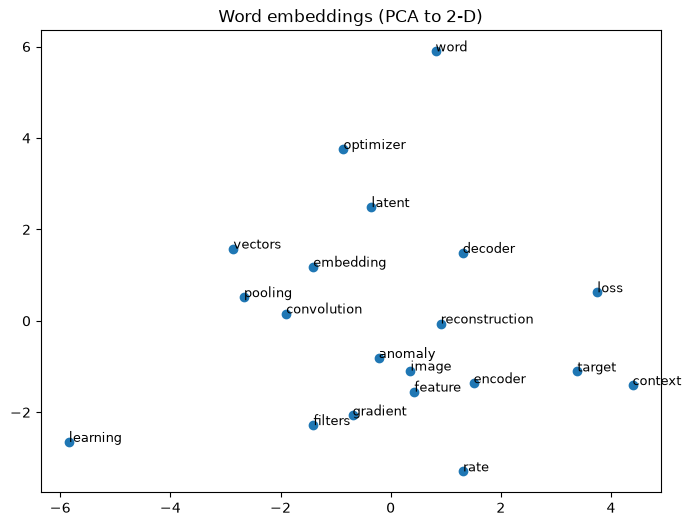

In [62]:
# 2-D view of the 50-D word vectors (PCA). Related words tend to sit close together.
words_to_plot = ["encoder", "decoder", "latent", "reconstruction", "anomaly",
                 "convolution", "filters", "image", "pooling", "feature",
                 "loss", "optimizer", "gradient", "learning", "rate",
                 "context", "target", "word", "embedding", "vectors"]
words_to_plot = [w for w in words_to_plot if w in word2idx]
pts = PCA(n_components=2).fit_transform(embeddings[[word2idx[w] for w in words_to_plot]])

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1])
for (x0, y0), w in zip(pts, words_to_plot):
    plt.annotate(w, (x0, y0), fontsize=9)
plt.title("Word embeddings (PCA to 2-D)"); plt.show()

In [ ]:
# Save the embeddings as tab-separated files (vectors + words).
# These can be viewed later in any embedding projector tool.
np.savetxt("p5_vectors.tsv", embeddings[1:], delimiter="\t", fmt="%.5f")
with open("p5_metadata.tsv", "w", encoding="utf-8") as f:
    f.write("\n".join(idx2word[1:]))
print("Saved p5_vectors.tsv and p5_metadata.tsv")

## Try it yourself (optional)

1. Change `WINDOW` to 1 and to 4. A small window captures grammar-like similarity; a large window captures topic-like similarity.
2. Change `EMBED_DIM` to 10 and to 100.
3. Add a few sentences of your own to `cbow_corpus.txt` and retrain.

Note: with a tiny corpus the similarities are rough. Real word embeddings (word2vec, GloVe) are trained on billions of words with exactly the same idea.

## Conclusion

We prepared a text corpus, generated (context, target) training pairs with a sliding window, trained a CBOW model in Keras, and used the learned embedding layer to predict missing words and find similar words.